## README:

This notebook evaluates the naive equal-allocation, buy-and-hold policy on the test set using a set of financial metrics.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from finrl.meta.preprocessor.preprocessors import data_split

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [3]:
from trading_environment.custom_env import StockTradingEnv
from trading_environment.rewards import PnLReward
from evaluation import financial_metrics

In [4]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Load and prepare data

In [5]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

base_columns = [
    'date',	'tic', 'close',	'high',	'low', 'open', 'volume'
]

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    # 'doy_sin',
    # 'doy_cos',
    'dow_sin',
    'dow_cos'
]

In [6]:
data_df = pd.read_csv(os.path.join(DATA_DIR, 'data_with_features.csv'))

data_df = data_df[base_columns + stock_features + economy_features]
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')

# get data attributes
nrows = data_df.shape[0]
n_per_tic = data_df['date'].nunique()
ntics = data_df['tic'].nunique()
tic_list = data_df['tic'].unique()

print('nrows', nrows)
print('rows per ticker:', n_per_tic)
print('n tickers', ntics)
print('tickers', tic_list)

nrows 67300
rows per ticker: 6730
n tickers 10
tickers ['AAPL' 'AMZN' 'F' 'JPM' 'MSFT' 'NVDA' 'PG' 'SPY' 'UNH' 'XOM']


In [7]:
data_df['date'].max()

Timestamp('2025-12-09 00:00:00')

In [8]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE + pd.Timedelta(days=1), end=max_date)

print(train_df.shape, trade_df.shape)
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

(47340, 19) (19950, 19)
Any missing values in training: False
Any missing values in testing: False


## Environment configuration

In [9]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 1000             # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 50        # number of previous time steps to encode
reward_scaling = 1      # reward scaling

In [10]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_function": PnLReward(),
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size,
    "starting_step": 0
}


In [11]:
trading_env = StockTradingEnv(df=trade_df, **env_kwargs)

## Execute naive policy - buy-and-hold (equal weight)

In [12]:
# initialize environment
obs, info = trading_env.reset()
obs.shape

(50, 69)

In [13]:
start_idx = 1 # exclude cash
end_idx = start_idx + stock_dim # include all prices
starting_prices = obs[-1, start_idx:end_idx] # get 'current' prices
print(starting_prices)
len(starting_prices)

[ 41.95957947  79.55000305   7.36982489  92.83546448  86.72167969
   6.15342474  64.40367126 243.68928528 198.96124268  51.56578827]


10

In [14]:
# first action: allocate all initial cash to buy equal number of shares per stock
n_shares = initial_amount / (sum(starting_prices) * (1 + buy_cost_pct))
# actions are a % of hmax
action = np.array([n_shares/hmax] * stock_dim)

print('action per stock:')
print(action)

action per stock:
[0.00569751 0.00569751 0.00569751 0.00569751 0.00569751 0.00569751
 0.00569751 0.00569751 0.00569751 0.00569751]


In [15]:
# commit first action
rewards = []
obs, reward, terminated, truncated, info = trading_env.step(actions=action)
rewards.append(reward)
print("PnL (transaction fees + stock value changes):", reward)

# check resulting shares
start_idx = 1 + stock_dim # exclude cash and prices
end_idx = start_idx + stock_dim # include all shares
shares = obs[-1, start_idx:end_idx] # get 'current' shares
print('Current shares:', shares)
print('Current cash:', obs[-1, 0])

PnL (transaction fees + stock value changes): -0.0005742124277539062
Current shares: [5.69751215 5.69751215 5.69751215 5.69751215 5.69751215 5.69751215
 5.69751215 5.69751215 5.69751215 5.69751215]
Current cash: 1.0231815394945443e-12


In [16]:
# keep holding shares until terminal state
hold = np.array([0] * stock_dim)

print('Holding start:', trading_env.current_step)
while not terminated:
    obs, reward, terminated, truncated, info = trading_env.step(actions=hold)
    rewards.append(reward)
print('Holding end:', trading_env.current_step)

Holding start: 50
Holding end: 1994


In [17]:
# prepare transactions dataframe for evaluation
lim = 1 + 2 * stock_dim  # cash + prices + shares
full_state_df = pd.DataFrame(trading_env.full_state_history[:, :lim])
full_state_df.columns = (
    ["cash"]
    + [f"price_{tic}" for tic in trading_env.tic_list]
    + [f"shares_{tic}" for tic in trading_env.tic_list]
)

### Performance Evaluation

In [18]:
# trading begins after window_size steps
# i.e. first state is at idx = window_size - 1
eval_df = full_state_df.iloc[window_size-1:]

In [19]:
financial_metrics.net_asset_change(eval_df)

np.float64(5814.220103704159)

In [20]:
metrics = financial_metrics.financial_performance(eval_df)
for k,v in metrics.items():
    print(k, np.round(v, 3))

total_return 2.158
CAGR 0.161
volatility 0.201
Sharpe 0.843
VaR 0.019
turnover 0.004


### Visualize trades

In [21]:
def visualize_trading(df):
    n_stocks = df.shape[1]

    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 0.8 * n_stocks), sharex=True)
    axes = axes.flatten()

    for ax, stock in zip(axes, df.columns):
        ax.plot(df.index, df[stock])
        ax.set_title(stock)
        ax.set_ylabel("Shares")
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

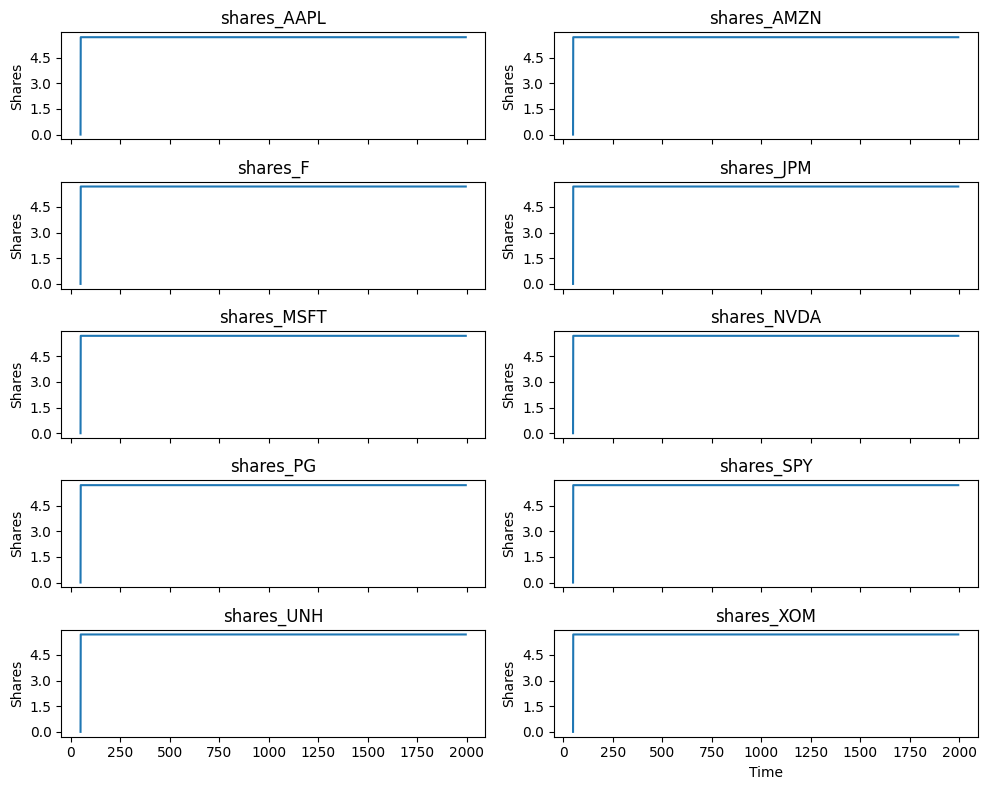

In [22]:
%matplotlib inline
share_cols = [col for col in eval_df.columns if 'share' in col]
visualize_trading(eval_df[share_cols])

## Financial metrics on train-test split

In [23]:
train_df2 = train_df[['tic', 'close']].pivot(columns='tic').reset_index(drop=True)
train_df2.columns = train_df2.columns.get_level_values(1)
trade_df2 = trade_df[['tic', 'close']].pivot(columns='tic').reset_index(drop=True)
trade_df2.columns = trade_df2.columns.get_level_values(1)

In [37]:
# generate metrics on stock prices on training and testing set
stock_eval = []
for col in train_df2.columns:
    series_train = train_df2[col].values
    series_test = trade_df2[col].values
    stock_eval.append({
        'stock': col,
        'cagr_train': financial_metrics.get_cagr(series_train, len(series_train)),
        'cagr_test': financial_metrics.get_cagr(series_test, len(series_test)),
        'sharpe_train': financial_metrics.get_sharpe_ratio(series_train),
        'sharpe_test': financial_metrics.get_sharpe_ratio(series_test)
    })
stock_eval = pd.DataFrame(stock_eval)
stock_eval.sort_values('sharpe_train', ascending=False).round(3)

,stock,cagr_train,cagr_test,sharpe_train,sharpe_test
0,AAPL,0.312,0.276,0.861,0.944
8,UNH,0.212,0.066,0.747,0.365
5,NVDA,0.291,0.581,0.718,1.149
1,AMZN,0.164,0.184,0.546,0.663
6,PG,0.064,0.083,0.401,0.501
9,XOM,0.070,0.089,0.400,0.434
7,SPY,0.058,0.143,0.390,0.781
4,MSFT,0.064,0.259,0.354,0.954
3,JPM,0.063,0.177,0.350,0.706
2,F,-0.022,0.060,0.157,0.346
